# Cinemath ML Notebook
### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix, ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Step 1 — Data Loading & Cleaning

In [2]:
# Load and combine all 10 Letterboxd review splits
review_files = [f'../final_data/letterboxd_review_data/letterboxd_split_{i}.csv' for i in range(1, 11)]
df_reviews = pd.concat([pd.read_csv(f) for f in review_files], ignore_index=True)

# Load and combine both TMDB movie data parts
movie_files = [
    '../final_data/tmdb_movie_data/movie_data_part1.csv',
    '../final_data/tmdb_movie_data/movie_data_part2.csv'
]
df_movies = pd.concat([pd.read_csv(f) for f in movie_files], ignore_index=True)

print('Reviews shape :', df_reviews.shape)
print('Movies shape  :', df_movies.shape)

Reviews shape : (10669089, 11)
Movies shape  : (285459, 60)


In [3]:
# Quick look at both datasets
print('--- Reviews ---')
print(df_reviews.dtypes)
print(df_reviews.isnull().sum())

print('\n--- Movies ---')
print(df_movies.dtypes)
print(df_movies.isnull().sum())

# Check target variable distribution
print('\nRelease Type Distribution:')
print(df_movies['release_type'].value_counts())

--- Reviews ---
username        object
tmdb_id        float64
movie_title     object
rating         float64
genre           object
subgenre_1      object
subgenre_2      object
subgenre_3      object
subgenre_4      object
subgenre_5      object
slug            object
dtype: object
username              0
tmdb_id          143037
movie_title           1
rating          2009873
genre            350574
subgenre_1      2327898
subgenre_2      5680933
subgenre_3      9379291
subgenre_4     10331339
subgenre_5     10624567
slug                446
dtype: int64

--- Movies ---
movie_id                      int64
release_decade              float64
production_companies         object
production_countries         object
revenue_x                   float64
profit_x                    float64
movie_age                   float64
release_date                 object
budget_x                    float64
name                         object
tmdb_id                       int64
release_year_x              

In [4]:
# Drop duplicate movie columns (keep _x versions as primary)
dup_cols = ['budget_y', 'revenue_y', 'runtime_y', 'original_language_y',
            'in_franchise_y', 'release_year_y', 'profit_y']
df_movies = df_movies.drop(columns=[c for c in dup_cols if c in df_movies.columns])

# Drop rows missing target variable
df_movies = df_movies.dropna(subset=['release_type'])

# Drop rows missing tmdb_id (needed for join)
df_movies = df_movies.dropna(subset=['tmdb_id'])
df_reviews = df_reviews.dropna(subset=['tmdb_id'])

# Drop duplicate movies
df_movies = df_movies.drop_duplicates(subset=['tmdb_id'])

# Drop duplicate (user, movie) pairs in reviews
df_reviews = df_reviews.drop_duplicates(subset=['username', 'slug'])

print('Reviews after cleaning :', df_reviews.shape)
print('Movies after cleaning  :', df_movies.shape)

Reviews after cleaning : (10296348, 11)
Movies after cleaning  : (121623, 53)


# Step 2 — Feature Engineering & Merging

In [5]:
# Aggregate review-level features per movie
review_agg = df_reviews.groupby('tmdb_id')['rating'].agg(
    avg_user_rating='mean',
    rating_std='std',
    rating_count='count'
).reset_index()
review_agg['rating_std'] = review_agg['rating_std'].fillna(0)

# Fill missing genre slots
genre_cols = ['genre', 'subgenre_1', 'subgenre_2', 'subgenre_3', 'subgenre_4', 'subgenre_5']
df_reviews[genre_cols] = df_reviews[genre_cols].fillna('Unknown')

print('Review aggregates shape:', review_agg.shape)

Review aggregates shape: (333558, 4)


In [6]:
# Merge movie data with review aggregates on tmdb_id
df = df_movies.merge(review_agg, on='tmdb_id', how='left')

# Fill missing review stats for movies with no reviews
df['avg_user_rating'] = df['avg_user_rating'].fillna(df['avg_user_rating'].median())
df['rating_std']      = df['rating_std'].fillna(0)
df['rating_count']    = df['rating_count'].fillna(0)

print('Merged shape:', df.shape)

Merged shape: (121623, 56)


In [7]:
# Select features for modeling
feature_cols = [
    # Movie characteristics
    'budget_x', 'revenue_x', 'runtime_x', 'profit_x', 'profit_margin',
    'movie_age', 'release_year_x', 'release_month', 'release_decade',
    # Production info
    'is_major_studio', 'is_us_production', 'n_production_countries',
    'production_company_count', 'in_franchise_x', 'belongs_to_collection',
    # Cast & crew
    'cast_size', 'cast_1_popularity', 'cast_2_popularity', 'cast_3_popularity',
    'director_popularity', 'director_prior_films', 'producer_count', 'star_power',
    # Social & audience
    'has_imdb', 'has_facebook', 'has_instagram', 'has_twitter', 'social_media_count',
    'vote_average', 'vote_count', 'popularity',
    # Keywords
    'keyword_count', 'kw_independent_film', 'kw_animation', 'kw_superhero',
    'kw_remake', 'kw_based_on_true_story', 'kw_sequel', 'kw_based_on_novel',
    'kw_documentary', 'kw_direct-to-video',
    # Review aggregates
    'avg_user_rating', 'rating_std', 'rating_count'
]

# Keep only cols that exist in df
feature_cols = [c for c in feature_cols if c in df.columns]

X = df[feature_cols].fillna(0)
y = (df['release_type'].str.lower().str.strip() == 'theatrical').astype(int)

print('Features (X):', X.shape)
print('Target (y)  :', y.shape)
print('\nClass balance:')
print(y.value_counts())

Features (X): (121623, 44)
Target (y)  : (121623,)

Class balance:
release_type
1    92611
0    29012
Name: count, dtype: int64


# Step 3 — Train/Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)

X_train: (91217, 44)
X_test : (30406, 44)


In [9]:
# Drop non-numeric columns that can't be scaled
non_numeric = X_train.select_dtypes(include=['object']).columns.tolist()
print("Dropping non-numeric columns:", non_numeric)

X_train = X_train.drop(columns=non_numeric)
X_test  = X_test.drop(columns=non_numeric)

print("X_train shape after drop:", X_train.shape)

Dropping non-numeric columns: ['belongs_to_collection']
X_train shape after drop: (91217, 43)


In [10]:
# Evaluation helper
def evaluate(name, y_train, y_train_pred, y_test, y_test_pred):
    print(f'{name}')
    print(f'  Train Accuracy : {accuracy_score(y_train, y_train_pred):.4f}')
    print(f'  Test  Accuracy : {accuracy_score(y_test,  y_test_pred):.4f}')
    print(f'  Test  F1 Score : {f1_score(y_test, y_test_pred, average="weighted"):.4f}')
    print(f'  Test  Precision: {precision_score(y_test, y_test_pred, average="weighted"):.4f}')
    print(f'  Test  Recall   : {recall_score(y_test, y_test_pred, average="weighted"):.4f}\n')

def plot_confusion(name, y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Streaming', 'Theatrical'])
    disp.plot(cmap='Blues')
    plt.title(f'{name} — Confusion Matrix')
    plt.tight_layout()
    plt.show()

# Step 4 — Baseline: Logistic Regression

In [11]:
# Drop non-numeric columns
non_numeric = X_train.select_dtypes(include=['object']).columns.tolist()
X_train = X_train.drop(columns=non_numeric)
X_test  = X_test.drop(columns=non_numeric)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Step 5 — Regularized Linear Models

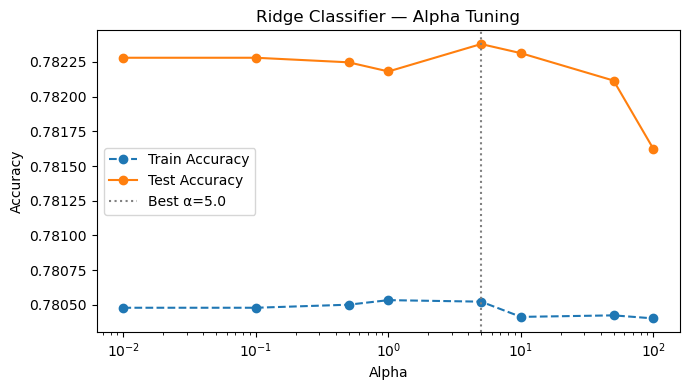

In [12]:
# Ridge Classifier — tune alpha
ridge_train_acc, ridge_test_acc = [], []
alphas = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]

for a in alphas:
    m = RidgeClassifier(alpha=a).fit(X_train_scaled, y_train)
    ridge_train_acc.append(accuracy_score(y_train, m.predict(X_train_scaled)))
    ridge_test_acc.append(accuracy_score(y_test,   m.predict(X_test_scaled)))

best_alpha_ridge = alphas[np.argmax(ridge_test_acc)]

plt.figure(figsize=(7, 4))
plt.plot(alphas, ridge_train_acc, 'o--', label='Train Accuracy')
plt.plot(alphas, ridge_test_acc,  'o-',  label='Test Accuracy')
plt.xscale('log')
plt.axvline(best_alpha_ridge, color='gray', linestyle=':', label=f'Best α={best_alpha_ridge}')
plt.xlabel('Alpha')
plt.ylabel('Accuracy')
plt.title('Ridge Classifier — Alpha Tuning')
plt.legend()
plt.tight_layout()
plt.show()

Ridge Classifier (α=5.0)
  Train Accuracy : 0.7805
  Test  Accuracy : 0.7824
  Test  F1 Score : 0.7289
  Test  Precision: 0.7617
  Test  Recall   : 0.7824



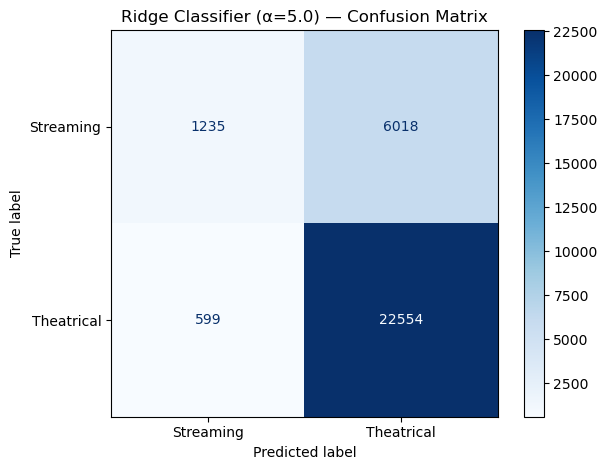

In [13]:
ridge = RidgeClassifier(alpha=best_alpha_ridge).fit(X_train_scaled, y_train)

evaluate(
    f'Ridge Classifier (α={best_alpha_ridge})',
    y_train, ridge.predict(X_train_scaled),
    y_test,  ridge.predict(X_test_scaled)
)
plot_confusion(f'Ridge Classifier (α={best_alpha_ridge})', y_test, ridge.predict(X_test_scaled))

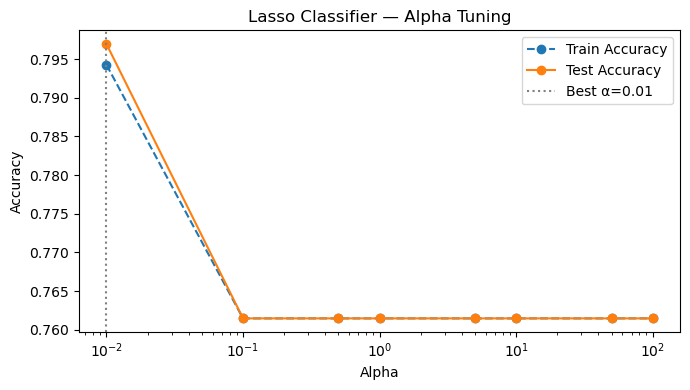

In [14]:
# Lasso (SGD with L1) — tune alpha
lasso_train_acc, lasso_test_acc = [], []

for a in alphas:
    m = SGDClassifier(loss='log_loss', penalty='l1', alpha=a, max_iter=1000, random_state=42)
    m.fit(X_train_scaled, y_train)
    lasso_train_acc.append(accuracy_score(y_train, m.predict(X_train_scaled)))
    lasso_test_acc.append(accuracy_score(y_test,   m.predict(X_test_scaled)))

best_alpha_lasso = alphas[np.argmax(lasso_test_acc)]

plt.figure(figsize=(7, 4))
plt.plot(alphas, lasso_train_acc, 'o--', label='Train Accuracy')
plt.plot(alphas, lasso_test_acc,  'o-',  label='Test Accuracy')
plt.xscale('log')
plt.axvline(best_alpha_lasso, color='gray', linestyle=':', label=f'Best α={best_alpha_lasso}')
plt.xlabel('Alpha')
plt.ylabel('Accuracy')
plt.title('Lasso Classifier — Alpha Tuning')
plt.legend()
plt.tight_layout()
plt.show()

Lasso Classifier (α=0.01)
  Train Accuracy : 0.7943
  Test  Accuracy : 0.7969
  Test  F1 Score : 0.7603
  Test  Precision: 0.7805
  Test  Recall   : 0.7969



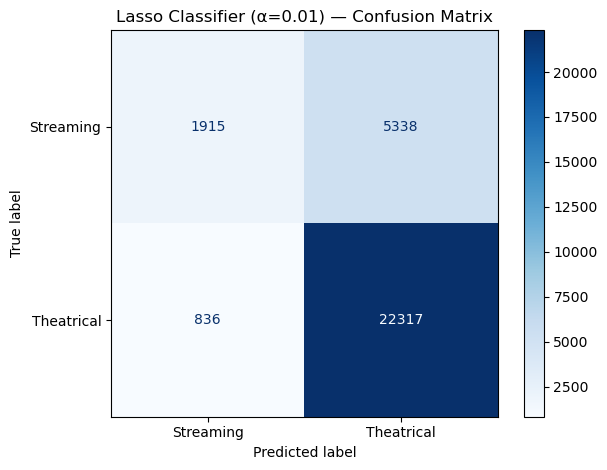

In [15]:
lasso = SGDClassifier(loss='log_loss', penalty='l1', alpha=best_alpha_lasso, max_iter=1000, random_state=42)
lasso.fit(X_train_scaled, y_train)

evaluate(
    f'Lasso Classifier (α={best_alpha_lasso})',
    y_train, lasso.predict(X_train_scaled),
    y_test,  lasso.predict(X_test_scaled)
)
plot_confusion(f'Lasso Classifier (α={best_alpha_lasso})', y_test, lasso.predict(X_test_scaled))

# Step 6 — KNN Classification

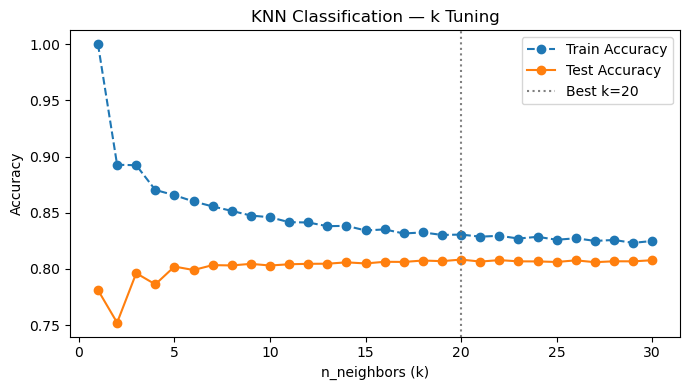

In [16]:
# KNN — tune n_neighbors
knn_train_acc, knn_test_acc = [], []
k_range = range(1, 31)

for k in k_range:
    m = KNeighborsClassifier(n_neighbors=k, n_jobs=-1).fit(X_train_scaled, y_train)
    knn_train_acc.append(accuracy_score(y_train, m.predict(X_train_scaled)))
    knn_test_acc.append(accuracy_score(y_test,   m.predict(X_test_scaled)))

best_k = list(k_range)[np.argmax(knn_test_acc)]

plt.figure(figsize=(7, 4))
plt.plot(k_range, knn_train_acc, 'o--', label='Train Accuracy')
plt.plot(k_range, knn_test_acc,  'o-',  label='Test Accuracy')
plt.axvline(best_k, color='gray', linestyle=':', label=f'Best k={best_k}')
plt.xlabel('n_neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN Classification — k Tuning')
plt.legend()
plt.tight_layout()
plt.show()

KNN Classification (k=20)
  Train Accuracy : 0.8306
  Test  Accuracy : 0.8083
  Test  F1 Score : 0.7971
  Test  Precision: 0.7947
  Test  Recall   : 0.8083



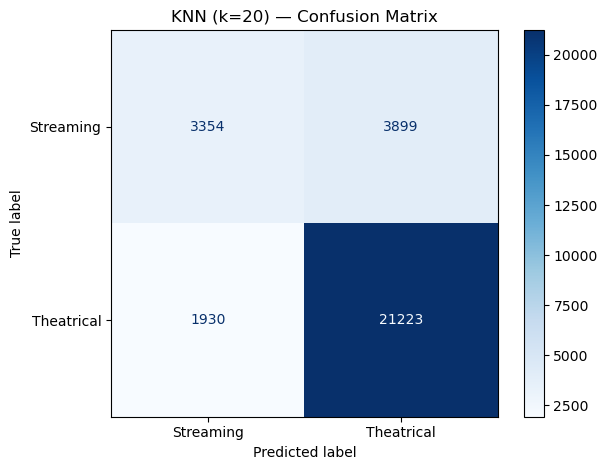

In [17]:
knn = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1).fit(X_train_scaled, y_train)

evaluate(
    f'KNN Classification (k={best_k})',
    y_train, knn.predict(X_train_scaled),
    y_test,  knn.predict(X_test_scaled)
)
plot_confusion(f'KNN (k={best_k})', y_test, knn.predict(X_test_scaled))

# Step 7 — Decision Tree

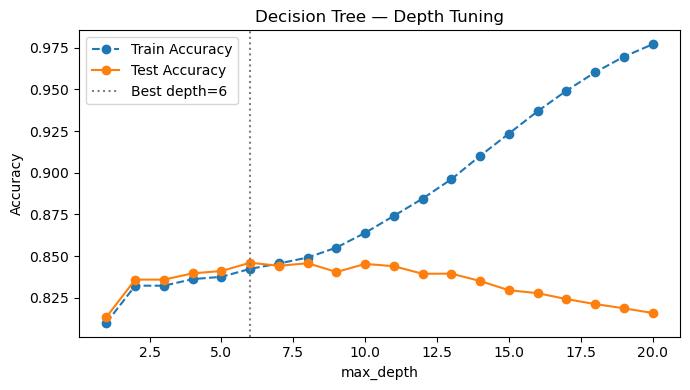

In [18]:
# Decision Tree — tune max_depth
dt_train_acc, dt_test_acc = [], []
depth_range = range(1, 21)

for d in depth_range:
    m = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    dt_train_acc.append(accuracy_score(y_train, m.predict(X_train)))
    dt_test_acc.append(accuracy_score(y_test,   m.predict(X_test)))

best_depth = list(depth_range)[np.argmax(dt_test_acc)]

plt.figure(figsize=(7, 4))
plt.plot(depth_range, dt_train_acc, 'o--', label='Train Accuracy')
plt.plot(depth_range, dt_test_acc,  'o-',  label='Test Accuracy')
plt.axvline(best_depth, color='gray', linestyle=':', label=f'Best depth={best_depth}')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree — Depth Tuning')
plt.legend()
plt.tight_layout()
plt.show()

Decision Tree (max_depth=6)
  Train Accuracy : 0.8424
  Test  Accuracy : 0.8461
  Test  F1 Score : 0.8435
  Test  Precision: 0.8419
  Test  Recall   : 0.8461



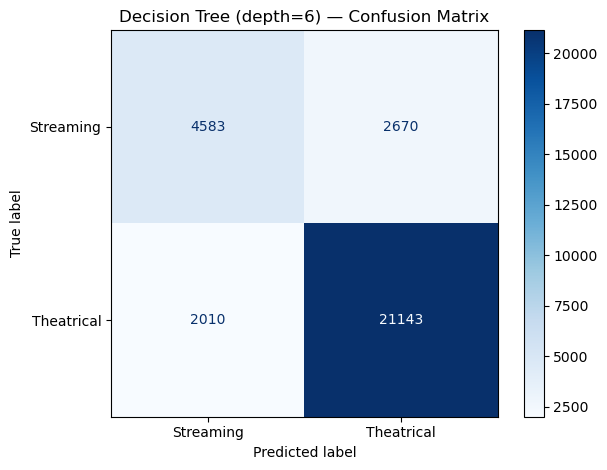

In [19]:
dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42).fit(X_train, y_train)

evaluate(
    f'Decision Tree (max_depth={best_depth})',
    y_train, dt.predict(X_train),
    y_test,  dt.predict(X_test)
)
plot_confusion(f'Decision Tree (depth={best_depth})', y_test, dt.predict(X_test))

# Step 8 — Random Forest

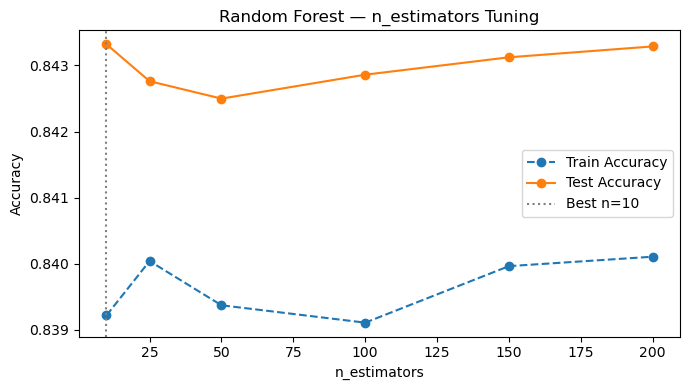

In [20]:
# Random Forest — tune n_estimators
rf_train_acc, rf_test_acc = [], []
estimator_range = [10, 25, 50, 100, 150, 200]

for n in estimator_range:
    m = RandomForestClassifier(n_estimators=n, max_depth=best_depth, random_state=42, n_jobs=-1)
    m.fit(X_train, y_train)
    rf_train_acc.append(accuracy_score(y_train, m.predict(X_train)))
    rf_test_acc.append(accuracy_score(y_test,   m.predict(X_test)))

best_n_estimators = estimator_range[np.argmax(rf_test_acc)]

plt.figure(figsize=(7, 4))
plt.plot(estimator_range, rf_train_acc, 'o--', label='Train Accuracy')
plt.plot(estimator_range, rf_test_acc,  'o-',  label='Test Accuracy')
plt.axvline(best_n_estimators, color='gray', linestyle=':', label=f'Best n={best_n_estimators}')
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.title('Random Forest — n_estimators Tuning')
plt.legend()
plt.tight_layout()
plt.show()

Random Forest (n=10, depth=6)
  Train Accuracy : 0.8392
  Test  Accuracy : 0.8433
  Test  F1 Score : 0.8414
  Test  Precision: 0.8401
  Test  Recall   : 0.8433



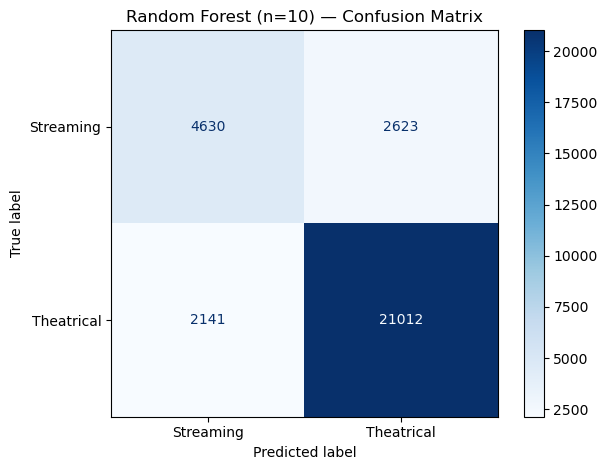

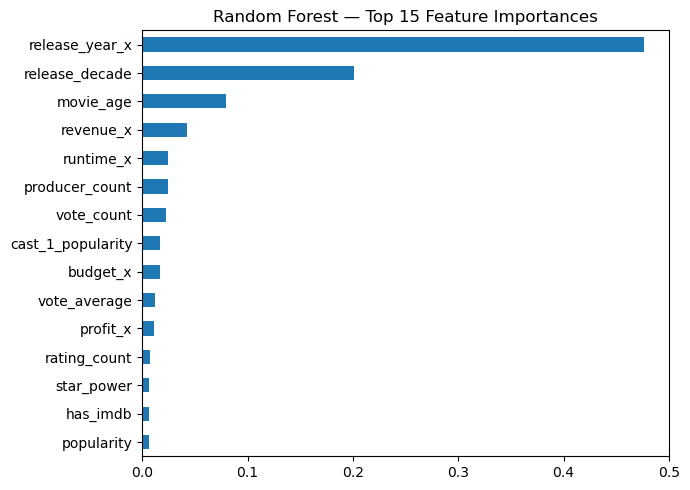

In [21]:
rf = RandomForestClassifier(
    n_estimators=best_n_estimators,
    max_depth=best_depth,
    random_state=42,
    n_jobs=-1
).fit(X_train, y_train)

evaluate(
    f'Random Forest (n={best_n_estimators}, depth={best_depth})',
    y_train, rf.predict(X_train),
    y_test,  rf.predict(X_test)
)
plot_confusion(f'Random Forest (n={best_n_estimators})', y_test, rf.predict(X_test))

# Feature importance
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns)
feat_imp.nlargest(15).sort_values().plot(
    kind='barh', figsize=(7, 5), title='Random Forest — Top 15 Feature Importances'
)
plt.tight_layout()
plt.show()

# Step 9 — Gradient Boosting

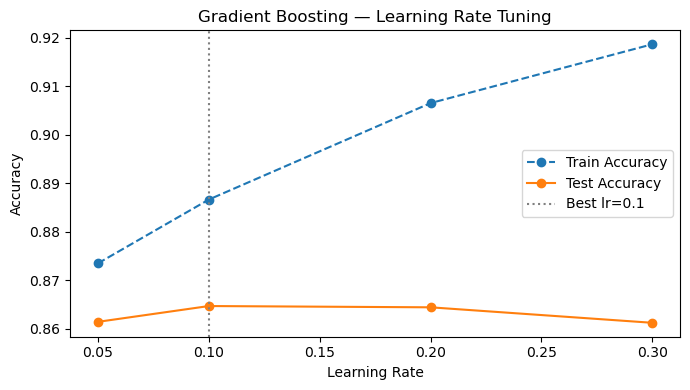

In [22]:
# Gradient Boosting — tune learning rate
gb_train_acc, gb_test_acc = [], []
lr_range = [0.05, 0.1, 0.2, 0.3]

for lr_val in lr_range:
    m = GradientBoostingClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=lr_val,
        subsample=0.8,
        max_features=0.8,
        random_state=42
    ).fit(X_train, y_train)
    gb_train_acc.append(accuracy_score(y_train, m.predict(X_train)))
    gb_test_acc.append(accuracy_score(y_test,   m.predict(X_test)))

best_lr = lr_range[np.argmax(gb_test_acc)]

plt.figure(figsize=(7, 4))
plt.plot(lr_range, gb_train_acc, 'o--', label='Train Accuracy')
plt.plot(lr_range, gb_test_acc,  'o-',  label='Test Accuracy')
plt.axvline(best_lr, color='gray', linestyle=':', label=f'Best lr={best_lr}')
plt.xlabel('Learning Rate')
plt.ylabel('Accuracy')
plt.title('Gradient Boosting — Learning Rate Tuning')
plt.legend()
plt.tight_layout()
plt.show()

Gradient Boosting (lr=0.1, n=300, depth=5)
  Train Accuracy : 0.8867
  Test  Accuracy : 0.8647
  Test  F1 Score : 0.8634
  Test  Precision: 0.8625
  Test  Recall   : 0.8647



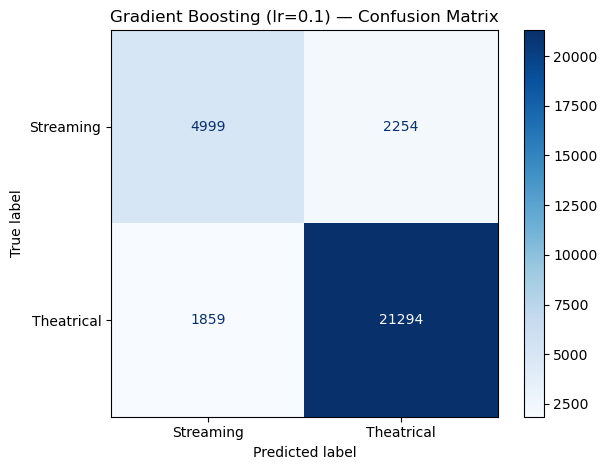

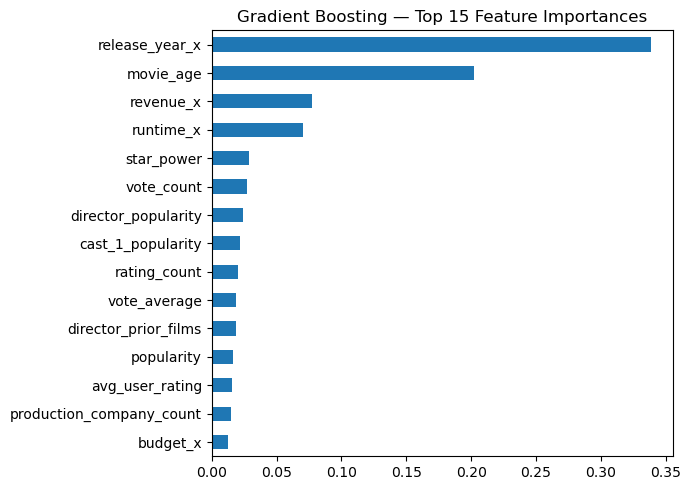

In [23]:
gb = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=best_lr,
    subsample=0.8,
    max_features=0.8,
    random_state=42
).fit(X_train, y_train)

evaluate(
    f'Gradient Boosting (lr={best_lr}, n=300, depth=5)',
    y_train, gb.predict(X_train),
    y_test,  gb.predict(X_test)
)
plot_confusion(f'Gradient Boosting (lr={best_lr})', y_test, gb.predict(X_test))

# Feature importance
feat_imp_gb = pd.Series(gb.feature_importances_, index=X_train.columns)
feat_imp_gb.nlargest(15).sort_values().plot(
    kind='barh', figsize=(7, 5), title='Gradient Boosting — Top 15 Feature Importances'
)
plt.tight_layout()
plt.show()

# Step 10 — Model Comparison

In [25]:
models = {
    'Ridge Classifier':    (ridge,   X_test_scaled),
    'Lasso Classifier':    (lasso,   X_test_scaled),
    'KNN':                 (knn,     X_test_scaled),
    'Decision Tree':       (dt,      X_test),
    'Random Forest':       (rf,      X_test),
    'Gradient Boosting':   (gb,      X_test),
}

results = []
for name, (model, X_eval) in models.items():
    preds = model.predict(X_eval)
    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, preds), 4),
        'F1 Score':  round(f1_score(y_test, preds, average='weighted'), 4),
        'Precision': round(precision_score(y_test, preds, average='weighted'), 4),
        'Recall':    round(recall_score(y_test, preds, average='weighted'), 4),
    })

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,F1 Score,Precision,Recall
0,Gradient Boosting,0.8647,0.8634,0.8625,0.8647
1,Decision Tree,0.8461,0.8435,0.8419,0.8461
2,Random Forest,0.8433,0.8414,0.8401,0.8433
3,KNN,0.8083,0.7971,0.7947,0.8083
4,Lasso Classifier,0.7969,0.7603,0.7805,0.7969
5,Ridge Classifier,0.7824,0.7289,0.7617,0.7824


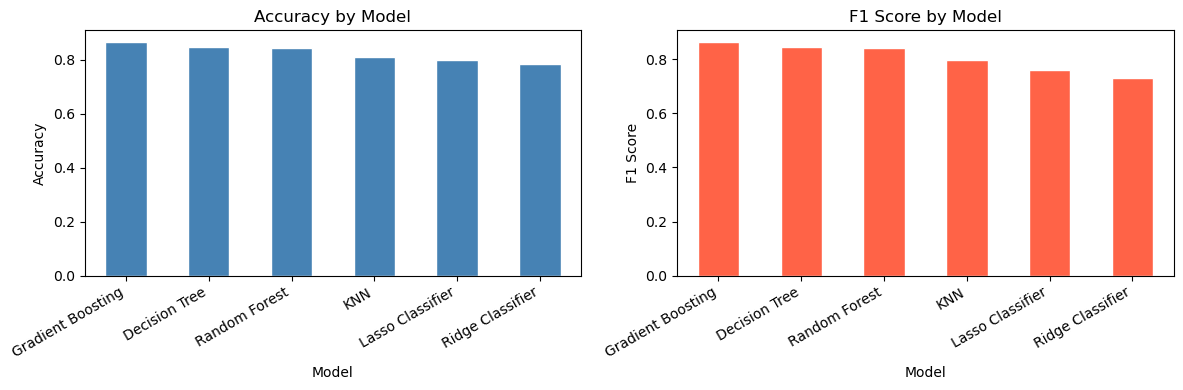

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

results_df.plot(
    x='Model', y='Accuracy', kind='bar',
    ax=axes[0], legend=False, color='steelblue', edgecolor='white'
)
axes[0].set_title('Accuracy by Model')
axes[0].set_xticklabels(results_df['Model'], rotation=30, ha='right')
axes[0].set_ylabel('Accuracy')

results_df.plot(
    x='Model', y='F1 Score', kind='bar',
    ax=axes[1], legend=False, color='tomato', edgecolor='white'
)
axes[1].set_title('F1 Score by Model')
axes[1].set_xticklabels(results_df['Model'], rotation=30, ha='right')
axes[1].set_ylabel('F1 Score')

plt.tight_layout()
plt.show()

# Step 11 — Prediction Demo

In [27]:
# Predict release type for a sample movie
sample_idx = 0
sample     = X_test.iloc[[sample_idx]]

actual    = 'Theatrical' if y_test.iloc[sample_idx] == 1 else 'Streaming'
predicted = 'Theatrical' if gb.predict(sample)[0] == 1 else 'Streaming'
proba     = gb.predict_proba(sample)[0]

print(f'Actual Release Type    : {actual}')
print(f'Predicted Release Type : {predicted}')
print(f'Confidence (Streaming) : {proba[0]:.2%}')
print(f'Confidence (Theatrical): {proba[1]:.2%}')

Actual Release Type    : Streaming
Predicted Release Type : Streaming
Confidence (Streaming) : 75.41%
Confidence (Theatrical): 24.59%
